In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src"))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "utils"))
import env_loader
env_loader.load_env()
from constants import (target_dict_mapping,
                        cancer_novelty_map, 
                        epic_map_cancer_to_group, 
                        epr_map_cancer_to_group,
                        CANCER_CODE_MAP,
                        epr_CHEMO_DRUG_MAP,
                        epic_CHEMO_DRUG_MAP)
import pandas as pd
import numpy as np

In [2]:
def mrn_inference_aero_from_anchored_notes(path_to_anchored_notes):
    df_anchored_notes = pd.read_csv(path_to_anchored_notes)
    df_anchored_notes['cancer_novelty'] = df_anchored_notes['primary_site_desc'].map(cancer_novelty_map)

    mrn_inference_aero = df_anchored_notes[df_anchored_notes['cancer_novelty'] == 0]['mrn'].unique().tolist()

    return mrn_inference_aero

def process_id_cancer_sites(df):
    df = df.copy()
        
    # Extract cancer columns
    cancer_cols = [col for col in df.columns if col.startswith("cancer_site_C")]

    # Melt into long format
    df_long = df.melt(
        id_vars=["treatment_date", 'mrn'],
        value_vars=cancer_cols,
        var_name="Cancer Code",
        value_name="Has Cancer"
    )

    df_long = df_long[df_long["Has Cancer"] == 1].copy()

    # Extract cancer code and map to type
    df_long["Cancer Code"] = df_long["Cancer Code"].str.replace("cancer_site_", "")
    df_long["Cancer Type"] = df_long["Cancer Code"].map(CANCER_CODE_MAP).fillna(df_long["Cancer Code"])
    df_long['Cancer Type'] = df_long['Cancer Type'].replace(epr_map_cancer_to_group)
    # if Has Cancer is 0, set Cancer Type to "Other/Ill-defined"
    df_long.loc[df_long["Has Cancer"] == 0, "Cancer Type"] = "Other/Ill-defined"

    return df_long

def process_od_cancer_sites(df):
    df['Cancer Type'] = df['primary_site_desc'].astype(str).apply(epic_map_cancer_to_group)
    
    return df[['mrn', 'treatment_date', 'Cancer Type']]

def process_target_columns(df):
    target_cols = [col for col in df.columns if col.startswith("target")]
    id_vars = [col for col in df.columns if col not in target_cols]
    # exclude any target column that contains (1pt_change|grade3plus|ecog)
    target_cols = [col for col in target_cols if not any(x in col for x in ["1pt_change", "grade3plus", "ecog"])]

    # keep all other columns and target_cols
    df = df[id_vars + target_cols].copy()
    # rename target columns such that '_' is replaced by '-'
    df.rename(columns=lambda x: x.replace("_", "-") if x.startswith("target") else x, inplace=True)
    # map target columns to more interpretable names
    df.rename(columns=target_dict_mapping, inplace=True)
    return df

def get_mrn_treatment_df(df):
    df = df.copy()
    df['treatment_date'] = (
        pd.to_datetime(df['treatment_date'], utc=True)
        .dt.normalize()
    )
    df['mrn'] = df['mrn'].astype(str)

    return (
        df[['mrn', 'treatment_date']]
        .drop_duplicates()
        .reset_index(drop=True)
    )

def process_drug_name(drug_df, mrn_treat_df, data_source):
    drug_df = drug_df.copy()

    if data_source == "epr":
        mrn_col = 'Hosp_Chart'
        treatment_col = 'Trt_Date'
        drug_col = 'Drug_name'
        drug_mapping = epr_CHEMO_DRUG_MAP
    elif data_source == "epic":
        mrn_col = 'mrn'
        treatment_col = 'treatment_date'
        drug_col = 'drug_name_normalized'
        drug_mapping = epic_CHEMO_DRUG_MAP
    else:
        raise ValueError(f"Unknown data_source: {data_source}")

    drug_list = set(drug_mapping.keys())

    # ---- standardize join keys ----
    drug_df[mrn_col] = drug_df[mrn_col].astype(str)
    drug_df[treatment_col] = (
        pd.to_datetime(drug_df[treatment_col], utc=True)
        .dt.normalize()
    )

    # ---- rename for clean join ----
    drug_df = drug_df.rename(
        columns={mrn_col: 'mrn', treatment_col: 'treatment_date'}
    )

    # ---- inner join on (mrn, treatment_date) ----
    drug_df_filtered = drug_df.merge(
        mrn_treat_df,
        on=['mrn', 'treatment_date'],
        how='inner'
    )

    # ---- keep only chemotherapy drugs ----
    drug_df_filtered = drug_df_filtered[
        drug_df_filtered[drug_col].isin(drug_list)
    ].copy()

    drug_df_filtered['Standardized Drug'] = (
        drug_df_filtered[drug_col].map(drug_mapping)
    )

    # make mrn int again
    drug_df_filtered['mrn'] = drug_df_filtered['mrn'].astype(int)

    return drug_df_filtered[['mrn', 'treatment_date', 'Standardized Drug']]

In [3]:
def build_characteristics_table(
    df_id,
    df_od,
    id_cancer,
    od_cancer,
    id_chemo,
    od_chemo,
    target_ae_cols,
    split_date,
    mrn_inference_aero
):
    
    split_date = pd.to_datetime(split_date, utc=True)


    # -------------------------
    # Helper functions
    # -------------------------
    def split_id_df(df):
        df = df.copy()
        df["treatment_date"] = pd.to_datetime(df["treatment_date"], utc=True)
        train = df[df["treatment_date"] <= split_date]
        temporal = df[df["treatment_date"] > split_date]
        return train, temporal


    def format_count(count, denom):
        pct = 100 * count / denom if denom > 0 else 0
        return f"{count:,} ({pct:.2f})"


    def format_median_iqr(series):
        med = np.median(series)
        q1 = np.percentile(series, 25)
        q3 = np.percentile(series, 75)
        return f"{med:.2f} ({q1:.2f}-{q3:.2f})"


    def frequency_table(df, col, total_patients):
        counts = df[col].value_counts().sort_index()
        out = {}
        for k, v in counts.items():
            out[k] = format_count(v, total_patients)
        return out, counts


    # -------------------------
    # Split data
    # -------------------------
    id_train, id_temporal = split_id_df(df_id)
    cancer_train, cancer_temporal = split_id_df(id_cancer)
    chemo_train, chemo_temporal = split_id_df(id_chemo)


    # -------------------------
    # Split OOD by cancer group
    # -------------------------
    df_od_aero = df_od[df_od["mrn"].isin(mrn_inference_aero)]
    df_od_other = df_od[~df_od["mrn"].isin(mrn_inference_aero)]


    # -------------------------
    # Column containers
    # -------------------------
    columns = {
        "Training": {},
        "Temporal OOD": {},
        "Multi-factor OOD": {},
        "OOD Aero": {},
        "OOD Other": {}
    }


    splits = {
        "Training": id_train,
        "Temporal OOD": id_temporal,
        "Multi-factor OOD": df_od,
        "OOD Aero": df_od_aero,
        "OOD Other": df_od_other
    }


    for name, df in splits.items():
        n = df.shape[0]


        columns[name]["Age, median (IQR)"] = format_median_iqr(df["age"])
        female_n = df["female"].sum()
        columns[name]["Female"] = format_count(female_n, n)


    # =========================
    # Adverse events
    # =========================
    for ae in target_ae_cols:
        for name, df in splits.items():
            valid = df[df[ae] != -1]
            denom = valid.shape[0]
            count = (valid[ae] == 1).sum()
            columns[name][ae] = format_count(count, denom)


    # =========================
    # Cancer type
    # =========================
    od_cancer_aero = od_cancer[od_cancer["mrn"].isin(mrn_inference_aero)]
    od_cancer_other = od_cancer[~od_cancer["mrn"].isin(mrn_inference_aero)]


    cancer_splits = {
        "Training": cancer_train,
        "Temporal OOD": cancer_temporal,
        "Multi-factor OOD": od_cancer,
        "OOD Aero": od_cancer_aero,
        "OOD Other": od_cancer_other
    }


    cancer_counts = {}


    for name, df in cancer_splits.items():
        total = df['mrn'].nunique()
        freq, raw = frequency_table(df, "Cancer Type", total)
        columns[name].update({f"Cancer: {k}": v for k, v in freq.items()})
        if name == "Training":
            cancer_counts = raw


    # =========================
    # Chemotherapy drugs
    # =========================
    od_chemo_aero = od_chemo[od_chemo["mrn"].isin(mrn_inference_aero)]
    od_chemo_other = od_chemo[~od_chemo["mrn"].isin(mrn_inference_aero)]


    chemo_splits = {
        "Training": chemo_train,
        "Temporal OOD": chemo_temporal,
        "Multi-factor OOD": od_chemo,
        "OOD Aero": od_chemo_aero,
        "OOD Other": od_chemo_other
    }


    drug_counts = {}


    for name, df in chemo_splits.items():
        # unique patients per drug
        df_unique = df.drop_duplicates(subset=["mrn", "Standardized Drug"])
        total_patients = df_unique["mrn"].nunique()


        counts = (
            df_unique
            .groupby("Standardized Drug")["mrn"]
            .nunique()
            .sort_values(ascending=False)
        )


        for drug, cnt in counts.items():
            columns[name][f"Chemo: {drug}"] = format_count(cnt, total_patients)


        if name == "Training":
            drug_counts = counts


    # =========================
    # Build final table
    # =========================
    table = pd.DataFrame(columns).fillna("0 (0)")


    # Ordering: demographics → AEs → cancer → chemo
    ordering = []


    ordering += ["Age, median (IQR)", "Female"]
    ordering += target_ae_cols


    # --- collect all cancer types across splits ---
    all_cancers = set()
    for df in cancer_splits.values():
        all_cancers.update(df["Cancer Type"].dropna().unique())


    # --- training counts ---
    train_cancer_counts = (
        cancer_train["Cancer Type"]
        .value_counts()
        .to_dict()
    )


    # --- ordering: descending training freq, then name ---
    ordered_cancers = sorted(
        all_cancers,
        key=lambda x: (-train_cancer_counts.get(x, 0), x)
    )


    ordering += [f"Cancer: {k}" for k in ordered_cancers]


    # --- collect all drugs across splits ---
    all_drugs = set()
    for df in chemo_splits.values():
        all_drugs.update(df["Standardized Drug"].dropna().unique())


    # --- training drug counts (patients per drug) ---
    train_drug_counts = (
        chemo_train
        .drop_duplicates(subset=["mrn", "Standardized Drug"])
        .groupby("Standardized Drug")["mrn"]
        .nunique()
        .to_dict()
    )


    # --- ordering: descending training freq, then name ---
    ordered_drugs = sorted(
        all_drugs,
        key=lambda x: (-train_drug_counts.get(x, 0), x)
    )


    ordering += [f"Chemo: {k}" for k in ordered_drugs]


    table = table.loc[ordering]


    # =========================
    # Create second table with limited chemo drugs and cancer types
    # =========================

    # --- training top 3 drugs (by %, descending) ---
    train_top3 = (
        chemo_train
        .drop_duplicates(subset=["mrn", "Standardized Drug"])
        .groupby("Standardized Drug")["mrn"]
        .nunique()
        .sort_values(ascending=False)
        .head(3)
        .index
    )

    print(train_top3)

    drug_rows = [f"Chemo: {d}" for d in train_top3]

    # --- compute "Other" row: all drugs not in top 3 ---
    for name, df in chemo_splits.items():
        df_unique = df.drop_duplicates(subset=["mrn", "Standardized Drug"])
        total_patients = df_unique["mrn"].nunique()
        other_mrns = (
            df_unique[~df_unique["Standardized Drug"].isin(train_top3)]["mrn"]
            .nunique()
        )
        table.loc["Chemo: Other", name] = format_count(other_mrns, total_patients)

    drug_rows += ["Chemo: Other"]

    # --- top 3 cancer types from Training, Temporal OOD, Multi-factor OOD (union) ---
    top3_cancer_cols = ["Training", "Temporal OOD", "Multi-factor OOD"]
    selected_cancers = set()
    for col_name in top3_cancer_cols:
        df = cancer_splits[col_name]
        top3 = (
            df["Cancer Type"]
            .value_counts()
            .head(3)
            .index
        )
        selected_cancers.update(top3)

    cancer_rows = [f"Cancer: {c}" for c in selected_cancers if f"Cancer: {c}" in table.index]

    # --- compute "Other" cancer row: all cancer types not in selected_cancers ---
    for name, df in cancer_splits.items():
        total = df["mrn"].nunique()
        other_mrns = (
            df[~df["Cancer Type"].isin(selected_cancers)]["mrn"]
            .nunique()
        )
        table.loc["Cancer: Other", name] = format_count(other_mrns, total)

    cancer_rows += ["Cancer: Other"]

    # --- keep all non-chemo, non-cancer rows ---
    non_chemo_cancer_rows = [
        r for r in table.index
        if not r.startswith("Chemo:") and not r.startswith("Cancer:")
    ]

    table_top_drugs_cancer = table.loc[non_chemo_cancer_rows + cancer_rows + drug_rows]


    return table, table_top_drugs_cancer

In [4]:
# open the anchored data
WORK_DIR = os.environ.get("WORK_DIR_HOME", "")
df_id = pd.read_csv(
    os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/data/train_test/note_anchored/note_anchored_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid.csv')
)
df_id['female'] = df_id['female'].astype(int)
df_id = process_target_columns(df_id)
id_mrn_treat_df = get_mrn_treatment_df(df_id)
df_od = pd.read_csv(
    os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/data/inference/note_anchored/note_anchored_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid.csv')
)
df_od = process_target_columns(df_od)
od_mrn_treat_df = get_mrn_treatment_df(df_od)
mrn_inference_aero = mrn_inference_aero_from_anchored_notes(os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/data/inference/note_anchored/note_anchored_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid.csv'))

In [5]:
# chemo data
H4H = os.environ.get("H4H_HOME", "")
id_chemo = pd.read_parquet(
    os.path.join(H4H, "2BLAST/data/final/data_2023-02-21/raw/opis.parquet.gzip")
)
id_chemo = process_drug_name(
    id_chemo, id_mrn_treat_df, data_source="epr"
)
od_chemo = pd.read_parquet(
    os.path.join(H4H, "2BLAST/data/final/data_2025-03-29/interim/chemo.parquet")
)
od_chemo = process_drug_name(
    od_chemo, od_mrn_treat_df, data_source="epic"
)

# cancer site
id_cancer = process_id_cancer_sites(df_id)
od_cancer = process_od_cancer_sites(df_od)

In [7]:
split_date = "2015-12-31"
target_ae_cols = list(target_dict_mapping.values())

paper_table, paper_table_subset = build_characteristics_table(
    df_id,
    df_od,
    id_cancer,
    od_cancer,
    id_chemo,
    od_chemo,
    target_ae_cols,
    split_date,
    mrn_inference_aero
)

Index(['CISPLATIN', 'FLUOROURACIL', 'GEMCITABINE'], dtype='object', name='Standardized Drug')


In [39]:
paper_table_subset

,Training,Temporal OOD,Multi-factor OOD,OOD Aero,OOD Other
"Age, median (IQR)",63.00 (55.00-70.00),65.00 (57.00-71.00),63.14 (53.23-71.64),64.27 (56.44-71.80),61.58 (47.95-71.39)
Female,"1,906 (40.99)",895 (39.64),"1,146 (46.01)",536 (37.72),610 (57.01)
Hb,704 (19.73),411 (21.80),548 (23.10),332 (24.20),216 (21.60)
ANC,"1,224 (34.40)",506 (26.86),390 (16.44),258 (18.80),132 (13.20)
Bili,96 (2.83),45 (2.46),38 (1.69),29 (2.24),9 (0.94)
PLT,246 (6.90),108 (5.73),114 (4.81),75 (5.47),39 (3.90)
ALT,134 (3.90),44 (2.38),72 (3.08),49 (3.61),23 (2.35)
AST,89 (2.58),35 (1.86),49 (2.10),34 (2.51),15 (1.53)
AKI,114 (3.26),68 (3.62),131 (5.56),75 (5.48),56 (5.66)
30d death,84 (1.82),32 (1.43),44 (1.80),33 (2.37),11 (1.04)


In [9]:
paper_table.to_csv("~/Desktop/paper_table.csv")

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def plot_prevalence_panels(df, fig_size_mm=None):
    """
    Plot 3-panel horizontal bar chart of toxicity prevalence.

    Parameters
    ----------
    df : pd.DataFrame
        Index = toxicity names. Columns include:
        'Training', 'Temporal OOD', 'Multi-factor OOD', 'OOD Aero', 'OOD Other'
        Each cell is formatted as 'yyy (zzz)' where zzz is prevalence out of 100.
    fig_size_mm : tuple, optional
        Figure size as (width_mm, height_mm). If None, defaults to (180, 90) mm.
    """

    fontsize_axes = 4
    fontsize_legend = 4

    if fig_size_mm is not None:
        figsize = (fig_size_mm[0] / 25.4, fig_size_mm[1] / 25.4)
    else:
        figsize = (180 / 25.4, 90 / 25.4)

    # ----------------------------
    # Parse helper: extract count and prevalence from 'yyy (zzz)' string
    # ----------------------------
    def parse_count(val):
        try:
            return float(str(val).split("(")[0].strip())
        except:
            return np.nan

    def parse_prevalence(val):
        try:
            return float(str(val).split("(")[1].replace(")", "").strip())
        except:
            return np.nan

    # ----------------------------
    # Build working dataframe
    # ----------------------------
    df_plot = pd.DataFrame(index=df.index)
    for col in ["Training", "Temporal OOD", "Multi-factor OOD", "OOD Aero", "OOD Other"]:
        df_plot[f"{col}_count"] = df[col].apply(parse_count)
        df_plot[f"{col}_prev"]  = df[col].apply(parse_prevalence)

    # ----------------------------
    # Order by Training prevalence, decreasing (top of chart = highest)
    # ----------------------------
    df_plot = df_plot.sort_values("Training_prev", ascending=True)  # ascending=True so highest is at top with invert_yaxis
    toxicities = df_plot.index.tolist()
    y_pos = np.arange(len(toxicities))

    # ----------------------------
    # Colors
    # ----------------------------
    BAR_COLOR       = "#4878CF"   # uniform color for all bars
    BAR_COLOR_DARK  = "#2c4a8a"   # darker shade for 'aero' sub-bar (panel 3)
    BAR_COLOR_LIGHT = "#91aee0"   # lighter shade for 'other' sub-bar (panel 3)

    target_type_colors = {
        'clinic': '#88bb99',
        'lab': '#e6b3bb',
        'symptom': '#9a91c4',
    }

    ae_category = {'Hb': 'lab', 'ANC': 'lab', 'Bili': 'lab', 'PLT': 'lab', 
                   'ALT': 'lab', 'AST': 'lab', 'AKI': 'lab', '30d death': 'clinic',
                   '1y death': 'clinic', 'ED visits': 'clinic', 'Depression': 'symptom', 
                   'Pain': 'symptom', 'Anxiety': 'symptom', 'Tired': 'symptom',
                   'Nausea': 'symptom', 'Drowsy': 'symptom', 'Appetite': 'symptom', 
                   'Well-being': 'symptom', 'Dyspnea': 'symptom'}

     # Map each toxicity to its bar color
    bar_colors = [target_type_colors[ae_category[t]] for t in toxicities]

    panel_cols   = ["Training", "Temporal OOD", "Multi-factor OOD"]
    panel_titles = ["Development", "Temporal shift", "Multiple shifts"]

    # ----------------------------
    # Plot
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False)

    for i, (col, subtitle) in enumerate(zip(panel_cols, panel_titles)):
        ax = axes[i]
        prev = df_plot[f"{col}_prev"].values

        if i < 2:
            # ----------------------------
            # Panels 1 & 2: plain bars
            # ----------------------------
            ax.barh(y_pos, prev, color=bar_colors, height=0.6)

        else:
            # ----------------------------
            # Panel 3: stacked sub-bars for Aero vs Other proportions
            # ----------------------------
            total_count = df_plot["Multi-factor OOD_count"].values
            aero_count  = df_plot["OOD Aero_count"].values
            other_count = df_plot["OOD Other_count"].values

            # Proportions of total Multi-factor OOD bar length
            with np.errstate(invalid='ignore', divide='ignore'):
                aero_prev  = np.where(total_count > 0,
                                      (aero_count  / total_count) * prev, 0)
                other_prev = np.where(total_count > 0,
                                      (other_count / total_count) * prev, 0)
                rest_prev  = np.clip(prev - aero_prev - other_prev, 0, None)

            # Draw stacked segments: aero | other | remainder
            # ax.barh(y_pos, aero_prev,
            #         color=BAR_COLOR_DARK,  height=0.6, label="aero")
            # ax.barh(y_pos, other_prev,
            #         color=BAR_COLOR_LIGHT, height=0.6, left=aero_prev, label="other")
            # ax.barh(y_pos, rest_prev,
            #         color=BAR_COLOR,       height=0.6, left=aero_prev + other_prev)
            ax.barh(y_pos, aero_prev,
                    color=bar_colors, height=0.6, alpha=1.0, label="aero")
            ax.barh(y_pos, other_prev,
                    color=bar_colors, height=0.6, left=aero_prev, alpha=0.6, label="other")
            ax.barh(y_pos, rest_prev,
                    color=bar_colors, height=0.6, left=aero_prev + other_prev, alpha=0.3)

            # ax.legend(fontsize=fontsize_legend, loc="lower right", framealpha=0.9)

            legend_handles = [
                mpatches.Patch(facecolor='gray', alpha=1.0, label="aero"),
                mpatches.Patch(facecolor='gray', alpha=0.6, label="other"),
            ]
            ax.legend(handles=legend_handles, fontsize=fontsize_legend,
                      loc="lower right", framealpha=0.9)

        # ----------------------------
        # Y-axis labels: only on the first panel
        # ----------------------------
        if i == 0:
            ax.set_yticks(y_pos)
            ax.set_yticklabels(toxicities, fontsize=fontsize_axes)
        else:
            ax.set_yticks(y_pos)
            ax.set_yticklabels([])

        # ----------------------------
        # Subtitle and axis labels
        # ----------------------------
        ax.set_title(subtitle, fontsize=fontsize_axes, fontweight="normal")
        ax.set_xlabel("prevalence (%)", fontsize=fontsize_axes)

        # ----------------------------
        # Spines: only left and bottom
        # ----------------------------
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.0)
        ax.spines['bottom'].set_color('black')

        ax.tick_params(axis='both', labelsize=fontsize_axes, pad=1)
        ax.grid(False)

    plt.tight_layout(pad=0.5)
    fig.set_size_inches(figsize[0], figsize[1])

    return fig

In [41]:
df_sub = paper_table_subset.iloc[2:21]
df_sub

,Training,Temporal OOD,Multi-factor OOD,OOD Aero,OOD Other
Hb,704 (19.73),411 (21.80),548 (23.10),332 (24.20),216 (21.60)
ANC,"1,224 (34.40)",506 (26.86),390 (16.44),258 (18.80),132 (13.20)
Bili,96 (2.83),45 (2.46),38 (1.69),29 (2.24),9 (0.94)
PLT,246 (6.90),108 (5.73),114 (4.81),75 (5.47),39 (3.90)
ALT,134 (3.90),44 (2.38),72 (3.08),49 (3.61),23 (2.35)
AST,89 (2.58),35 (1.86),49 (2.10),34 (2.51),15 (1.53)
AKI,114 (3.26),68 (3.62),131 (5.56),75 (5.48),56 (5.66)
30d death,84 (1.82),32 (1.43),44 (1.80),33 (2.37),11 (1.04)
1y death,"1,604 (36.94)",669 (32.84),528 (26.72),364 (33.03),164 (18.76)
ED visits,367 (8.31),292 (13.33),250 (10.36),170 (12.43),80 (7.65)


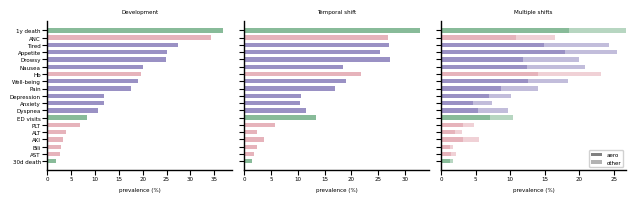

In [ ]:
fig = plot_prevalence_panels(df_sub, fig_size_mm=(160,50));

In [ ]:
fig.savefig("prevalence_across_splits.svg")